#Shail Rawat
#2501940011
#Deep Learning Architectures and Techniques (ETMMDL274)
---------------------------------------------------------------------------------------------
# **ASSIGNMENT - 2**
##**Multiclass Image Classification Using Convolutional Neural Networks and Transfer Learning**
This laboratory assignment introduces students to Convolutional Neural Networks (CNNs) for
image classification. Students will design a basic CNN and then apply transfer learning using
a pretrained model to perform multiclass object recognition, reinforcing core Unit II concepts
such as convolution, pooling, data augmentation, and evaluation metrics.


1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


2. Import dataset and neural network tools from TensorFlow

In [2]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

3. Import evaluation metrics

In [3]:
from sklearn.metrics import confusion_matrix, classification_report


4. Load Fashion MNIST Dataset

In [4]:
# Dataset contains 28x28 grayscale images of clothing items
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


5. Data Preprocessing


In [5]:
# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape data to add channel dimension (required for CNN)
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Convert labels to categorical format (One-Hot Encoding)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

6. Build CNN Model

In [6]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten feature maps into a vector
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128,activation='relu'))

# Dropout to reduce overfitting
model.add(Dropout(0.5))

# Output Layer (10 classes)
model.add(Dense(10,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7. Compile Model

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


8. Train Model

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 28ms/step - accuracy: 0.7297 - loss: 0.7526 - val_accuracy: 0.8536 - val_loss: 0.3867
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.8569 - loss: 0.3965 - val_accuracy: 0.8824 - val_loss: 0.3223
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.8820 - loss: 0.3285 - val_accuracy: 0.8911 - val_loss: 0.3050
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.8902 - loss: 0.3033 - val_accuracy: 0.8967 - val_loss: 0.2897
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.8978 - loss: 0.2821 - val_accuracy: 0.9008 - val_loss: 0.2701
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9065 - loss: 0.2579 - val_accuracy: 0.9013 - val_loss: 0.2700
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9126 - loss: 0.2386 - val_accuracy: 0.9043 - val_loss: 0.2666
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9152 -

9. Plot Training vs Validation Accuracy


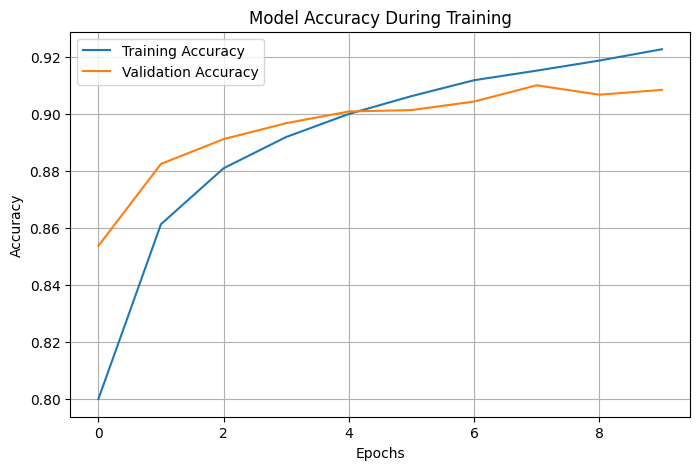

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy During Training")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


10. Make Predictions


In [10]:
pred = model.predict(X_test)

# Convert probabilities to class labels
pred = np.argmax(pred,axis=1)
true = np.argmax(y_test,axis=1)



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


11. Confusion Matrix


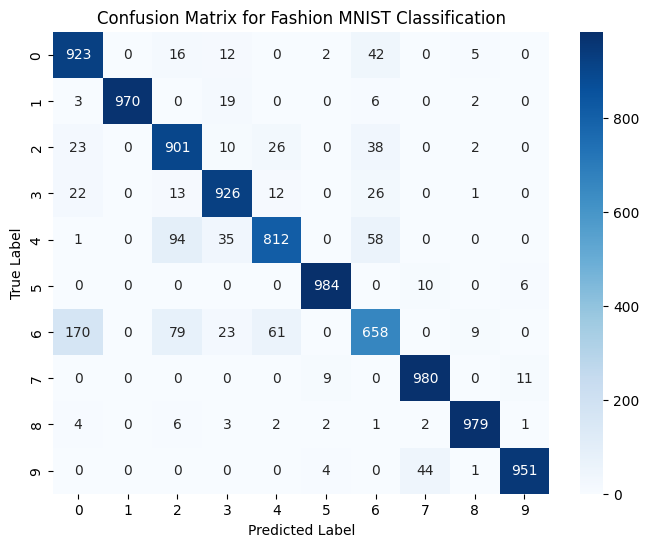

In [11]:
cm = confusion_matrix(true,pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix for Fashion MNIST Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()



12. Classification Report


In [12]:

print("Classification Report:\n")
print(classification_report(true,pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1000
           1       1.00      0.97      0.98      1000
           2       0.81      0.90      0.85      1000
           3       0.90      0.93      0.91      1000
           4       0.89      0.81      0.85      1000
           5       0.98      0.98      0.98      1000
           6       0.79      0.66      0.72      1000
           7       0.95      0.98      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

